# Assignment 2
## Part 2 - Evaluating time series

### 2B - A pair of series: cross-correlation and lead/lag

Dataset 1: RAPID 26°N 
- Project: RAPID-AMOC 26°N array
- Description: RAPID 26N transport estimates dataset
- DOI: https://doi.org/10.5285/48d0bf43-0598-ceb2-e063-7086abc062f1
- Source File: meridional_transports.nc
- Data Product: RAPID meridional transport data
- Time Coverage: 2004-04-06 to 2024-03-22
- Record Length: 730 observations (20.0 years)
- Sampling Frequency: 240.0H -> 10-day low pass filter
- missing: 0.0%

Dataset 2: NOAC 47°N
- Project: Meridional Connectivity of a 25-Year Observational AMOC Record at 47°N
- Description: No description available
- Source File: NOAC_AMOC.tab
- Data Product: Basin-wide AMOC volume transport from the NOAC array at 47°N in the subpolar North Atlantic (1993-2018)
- License: CC-BY-4.0
- Time Coverage: 1993-01-01 to 2018-01-01
- Record Length: 301 observations (25.0 years)
- Sampling Frequency: monthly
- missing: 0.0%

In [5]:
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from amocatlas import read
from amoc_analysis.correlation_trends.data_io import load_moc_sigma0_26n, load_47n

# 26N RAPID overturning in density coordinates: MOC_SIGMA0
rapid_raw = load_moc_sigma0_26n()

# 47N NOAC overturning (monthly) in density coordinates: MOC_SIGMA0
noac_time, noac_values = load_47n()

Loading 1 RAPID 26°N dataset(s):
  0. meridional_transports.nc: RAPID meridional transport data

Loading 1 NOAC 47°N dataset(s):
  0. NOAC_AMOC.tab: Basin-wide AMOC volume transport from the NOAC array at 47°N in the subpolar North Atlantic (1993-2018)



In [7]:
import pandas as pd
import xarray as xr

# put raw arrays into data arrays
rapid = xr.DataArray(
    rapid_raw[1],
    coords={'TIME': ('TIME', pd.to_datetime(rapid_raw[0]))},
    dims='TIME',
)

noac = xr.DataArray(
    noac_values,
    coords={'TIME': ('TIME', pd.to_datetime(noac_time))},
    dims='TIME',
)

# resample RAPID 10-day to monthly
rapid_monthly = rapid.resample(TIME='MS').mean()

# find time overlap
start = max(rapid_monthly.TIME.min(), noac.TIME.min())
end   = min(rapid_monthly.TIME.max(), noac.TIME.max())
print(f'Common period: {start.values} to {end.values}')

# select data from overlap period
rapid_subset = rapid_monthly.sel(TIME=slice(start, end))
noac_subset  = noac.sel(TIME=slice(start, end))

Common period: 2004-04-01T00:00:00.000000000 to 2018-01-01T00:00:00.000000


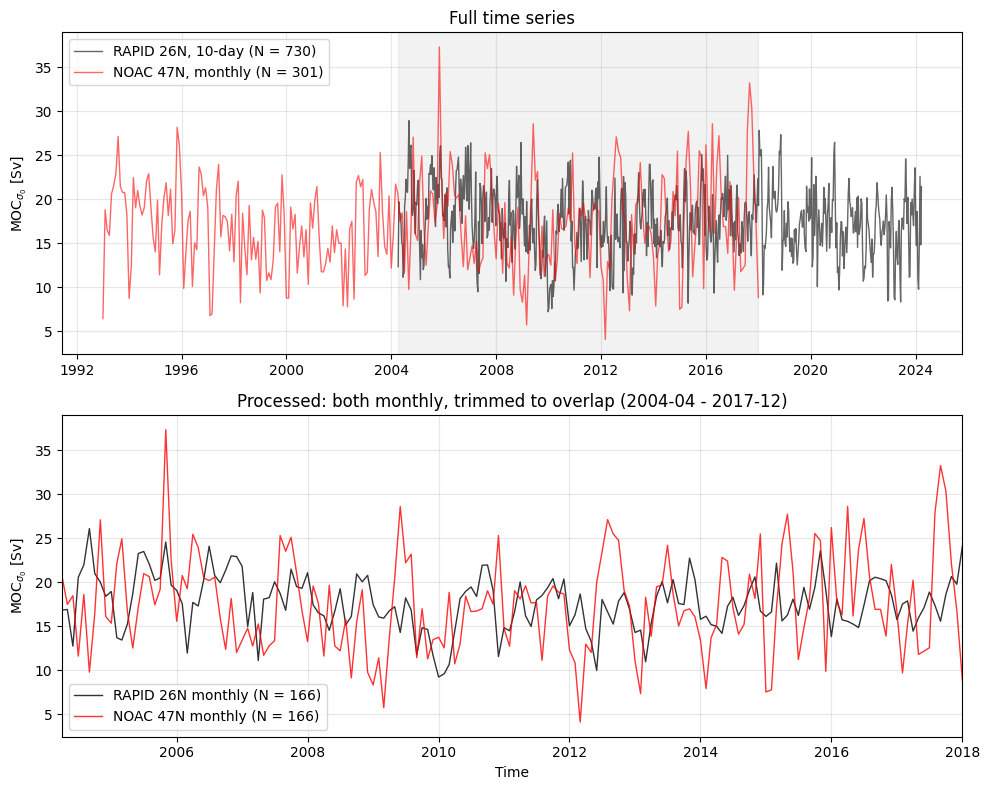

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# plot before: "raw" data sets
ax1.plot(rapid.TIME, rapid.values, lw=1, alpha=0.6, c='k', label=f'RAPID 26N, 10-day (N = {rapid.sizes['TIME']})')
ax1.plot(noac.TIME, noac.values, lw=1, alpha=0.6, c='r', label=f'NOAC 47N, monthly (N = {noac.sizes['TIME']})')

# highlight overlap time period
ax1.axvspan(start.values, end.values, color='grey', alpha=0.1)

ax1.grid(alpha=0.3)
ax1.set_ylabel('MOC$_{\\sigma_0}$ [Sv]')
ax1.set_title('Full time series')
ax1.legend()

# plot after: monthly, overlap
ax2.plot(rapid_subset.TIME, rapid_subset.values, lw=1, alpha=0.8, c='k', label=f'RAPID 26N monthly (N = {rapid_subset.sizes['TIME']})')
ax2.plot(noac_subset.TIME, noac_subset.values, lw=1, alpha=0.8, c='r', label=f'NOAC 47N monthly (N = {noac_subset.sizes['TIME']})')

ax2.set_xlim(start.values, end.values)
ax2.set_title('Processed: both monthly, trimmed to overlap (2004-04 - 2017-12)')
ax2.set_ylabel('MOC$_{\\sigma_0}$ [Sv]')
ax2.set_xlabel('Time')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
# plt.savefig('fig_2b_matched_series.png', dpi=150)
plt.show()